# Site-collapsed raw (before-WZA) mirror Manhattans — SNP vs SV, LFMM, clq0.9 TILING, all 20 axes

**Site twin** of `raw_manhattan_snp_vs_sv_lfmm_tile.ipynb`. The per-record LFMM p here is
computed on the **site-mean Δp** — the mean allele-frequency change across the ~11 pools
within each of the **31 sites** — then `lfmm_ridge(K=1)` + `lfmm_test`. The pool notebook
treats all 352 pools as independent; that pseudoreplication inflates the pool scan
(genomic-inflation λ≈2.5). Collapsing pools→sites removes that design effect (site λ≈1.7–1.8)
and, more usefully, acts as a **filter**: a pool peak driven by a few correlated pools within
a site *collapses* at site level, while a genuinely site-coherent climate association *persists*.
`K=1` is the site-level operating point (at n=31, larger K re-inflates by overfitting).

Per-record `wza_in_clq09_tile_site` p-values (site-level RAW lfmm p, `pval`) — one figure per
climate axis (bio1-19 + pc1), SNP up, sv down. Dashed = per-class Bonferroni (0.05/n records).
QQ panel shows the per-axis genomic-inflation λ (compare to the pool notebook's ≈2–2.5).
Vertical dotted line + gene label = a tiling block whose lead sv record is Bonferroni-sig
while its lead SNP record in the same block is not ("new" peak, first-pass).

In [1]:
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import lib
GEA = lib.GEA
WZAIN = f"{GEA}/phase1_replication/results/multiaxis/wza_in_clq09_tile_site"
AXES = [f"bio{i}" for i in range(1, 20)] + ["pc1"]
MODEL = "lfmm"
CLS = "sv"
CHROM_LEN = {"Chr1":30427671,"Chr2":19698289,"Chr3":23459830,"Chr4":18585056,"Chr5":26975502}
CH = list(CHROM_LEN); OFF = {}; _a = 0
for _c in CH: OFF[_c] = _a; _a += CHROM_LEN[_c]
plt.rcParams.update({"figure.dpi":110})
SNP_DARK, SNP_LIGHT = "#495057", "#ADB5BD"
CLS_DARK  = "#c0392b" if CLS == "sv" else "#1B5E20"
CLS_LIGHT = "#e8a58c" if CLS == "sv" else "#66BB6A"

def block_spans_tiling(r2=0.9):
    """Tiling block spans: each block absorbs the preceding gap (matches reblock_blockdef.py)."""
    tag=f"clq{r2}"; rows=[]
    for ci in range(1,6):
        ch = f"Chr{ci}"
        g=pd.read_csv(f"{lib.CLQ_BLOCKS_DIR}/chr{ci}_{tag}_blocks_{tag}.tsv",sep="\t").sort_values("start_pos").reset_index(drop=True)
        ends = g.end_pos.to_numpy(np.int64)
        for i in range(len(g)):
            lo = 1 if i == 0 else int(ends[i-1]) + 1
            hi = int(ends[i]) if i < len(g)-1 else 10**9
            rows.append((f"{ch}_{i}", ch, lo, hi))
    return pd.DataFrame(rows,columns=["block","chrom","start","end"]).set_index("block")
SPANS=block_spans_tiling(); GENES=lib.load_genes()
def genes_on(block):
    if block not in SPANS.index: return []
    s=SPANS.loc[block]; gc=GENES[(GENES.chrom==s.chrom)&(GENES.end>=s.start)&(GENES.start<=s.end)]
    return list(gc.gene)
print("loaded:", len(SPANS), "tiling blocks,", len(GENES), "genes ; class =", CLS)

loaded: 58376 tiling blocks, 27206 genes ; class = sv


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


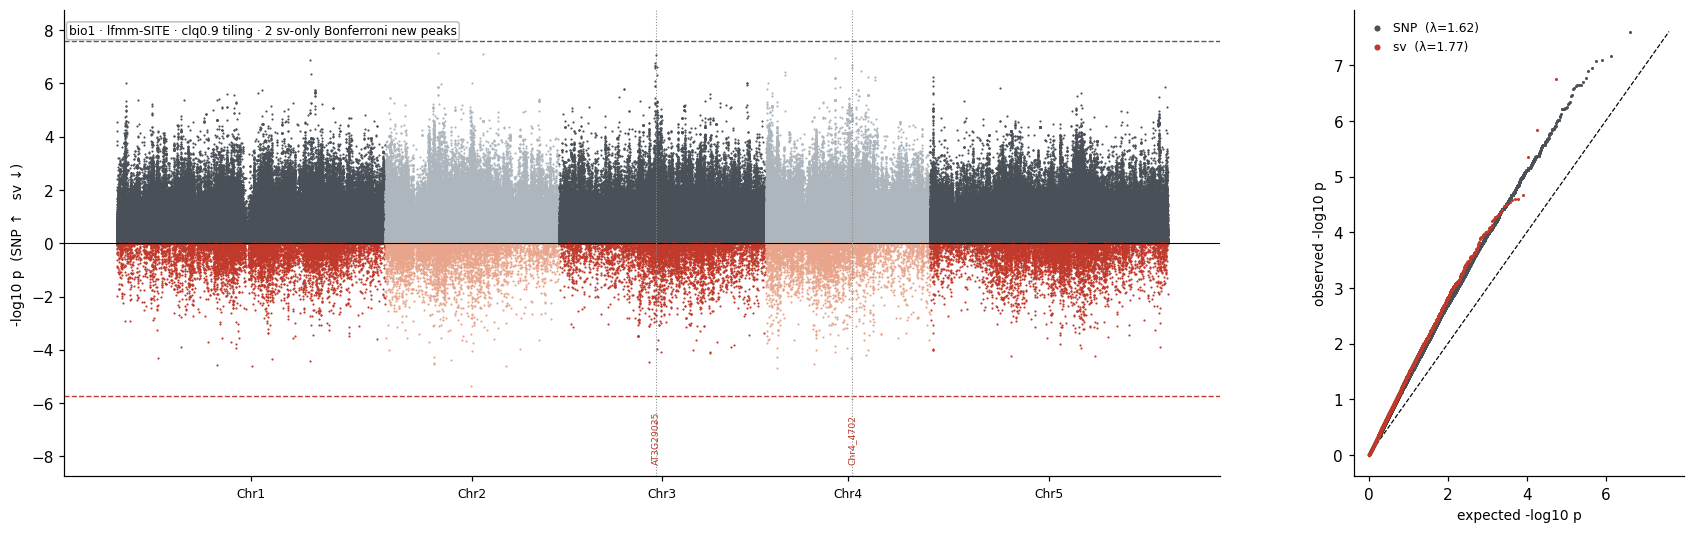

bio1: 2 sv-only Bonferroni new peaks (gene-bearing: 1)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
2306,Chr3_5945,Chr3,11035192,AT3G29035;AT3G29040;AT3G29050;AT3G29060,6.758382,7.076480
3160,Chr4_4702,Chr4,9755693,,5.832597,6.703343


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


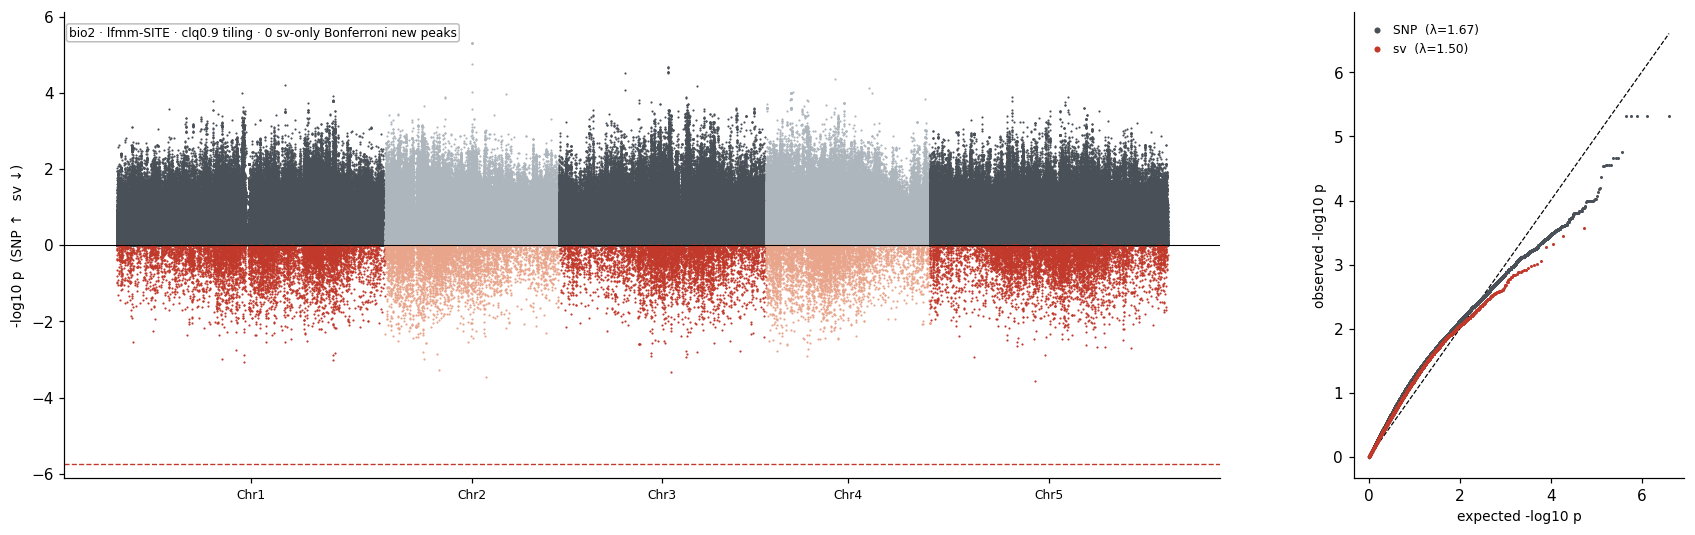

bio2: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


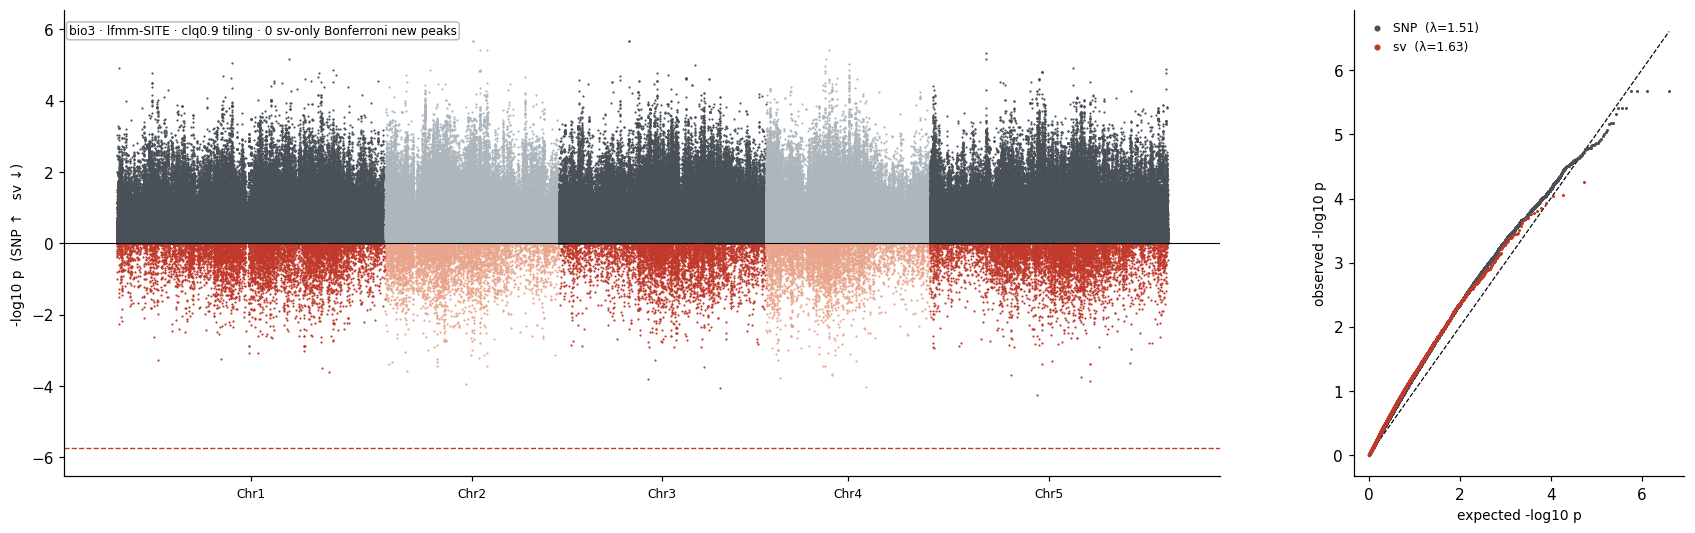

bio3: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


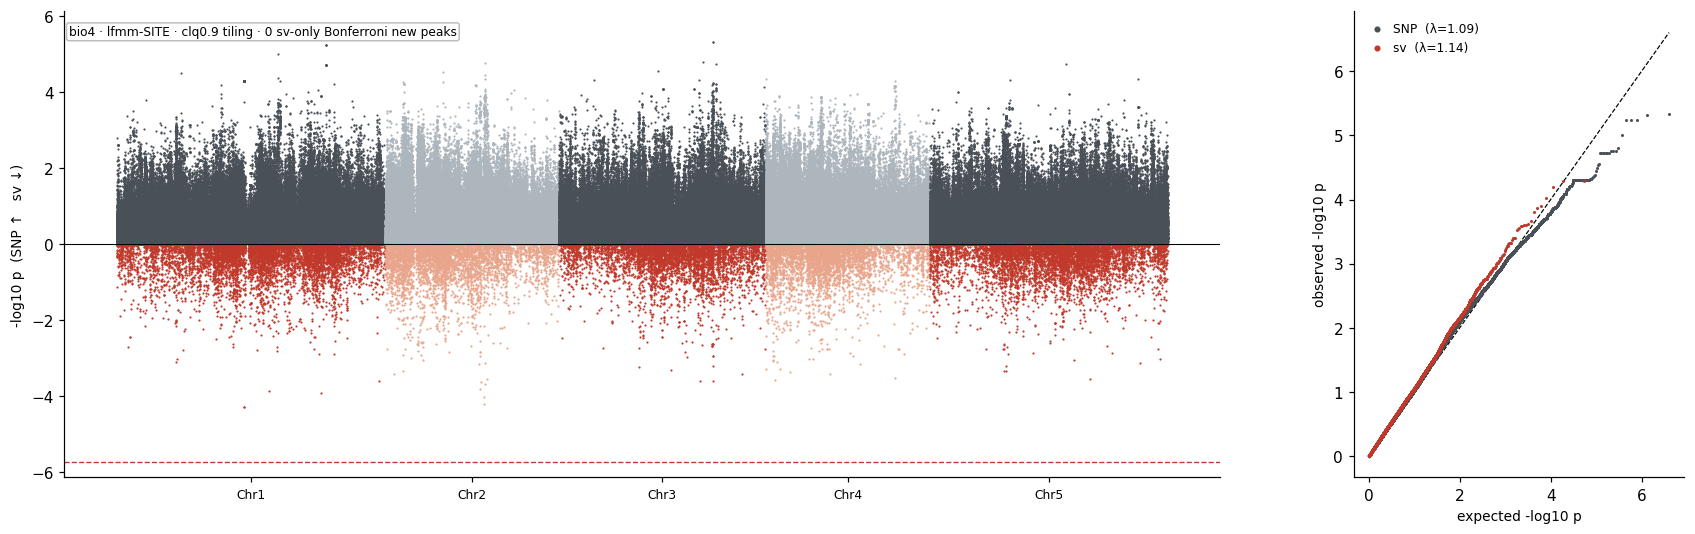

bio4: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


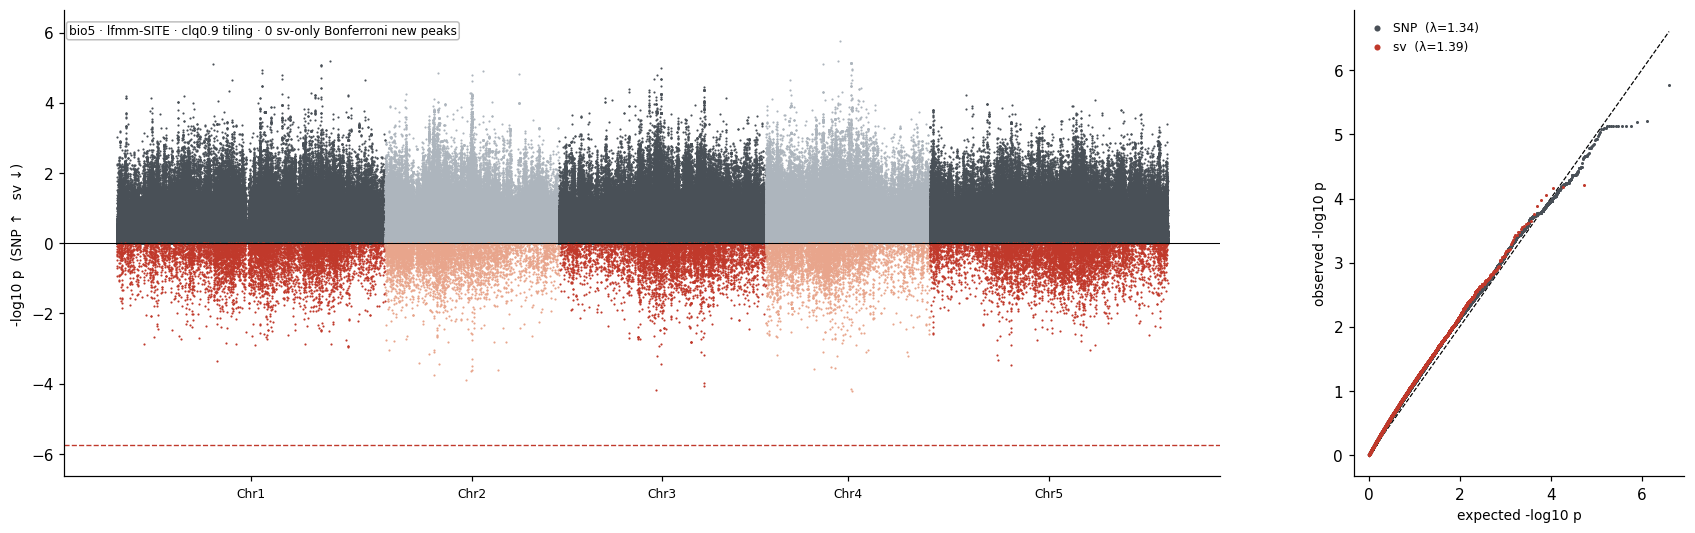

bio5: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


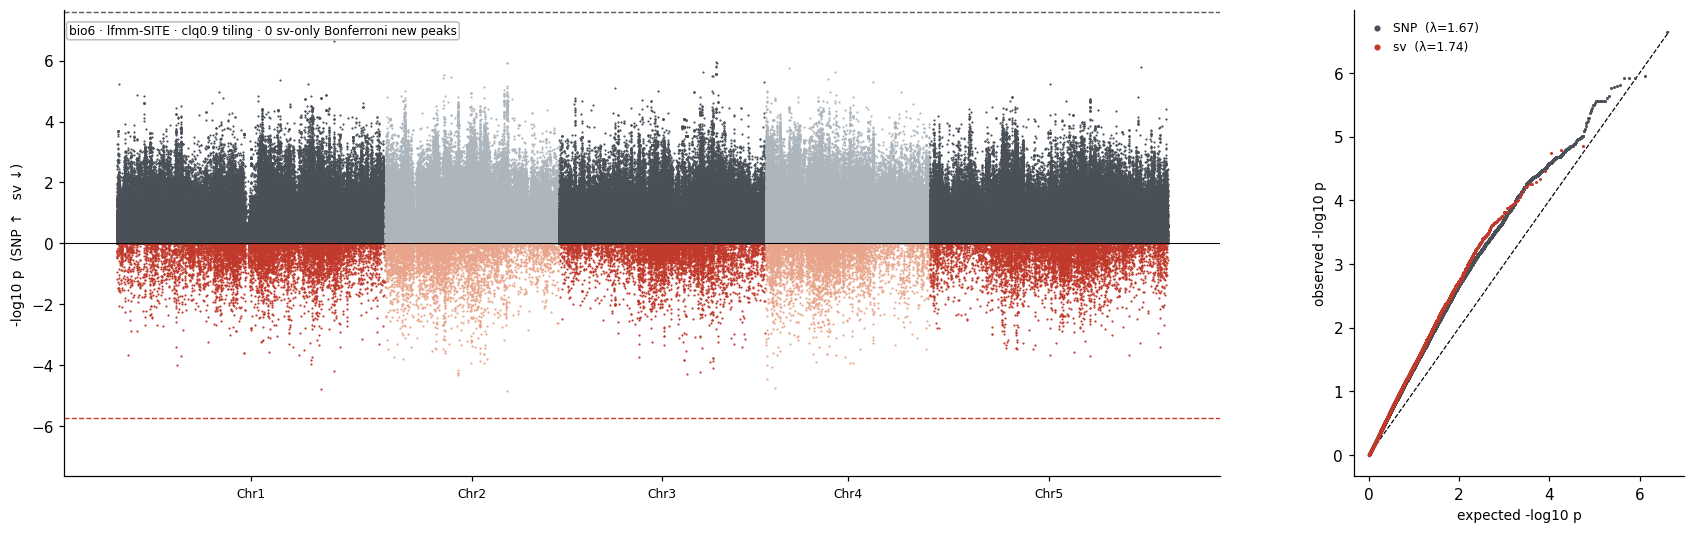

bio6: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


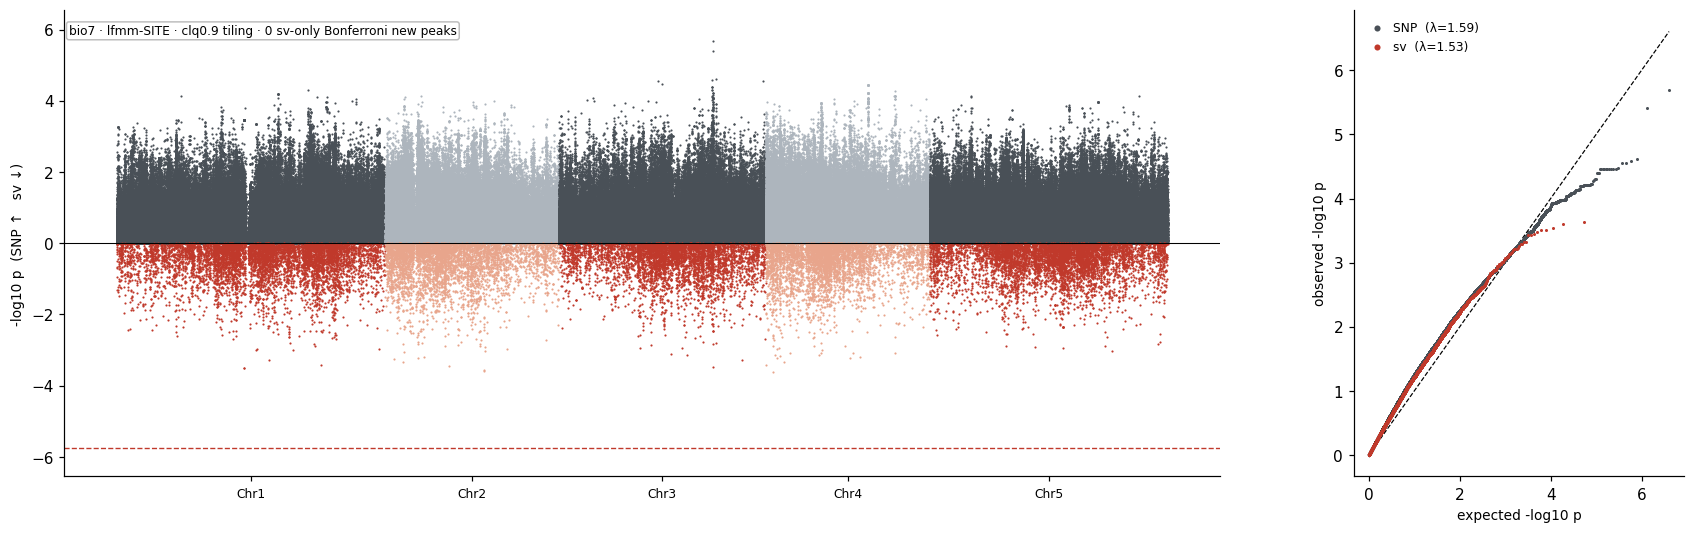

bio7: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


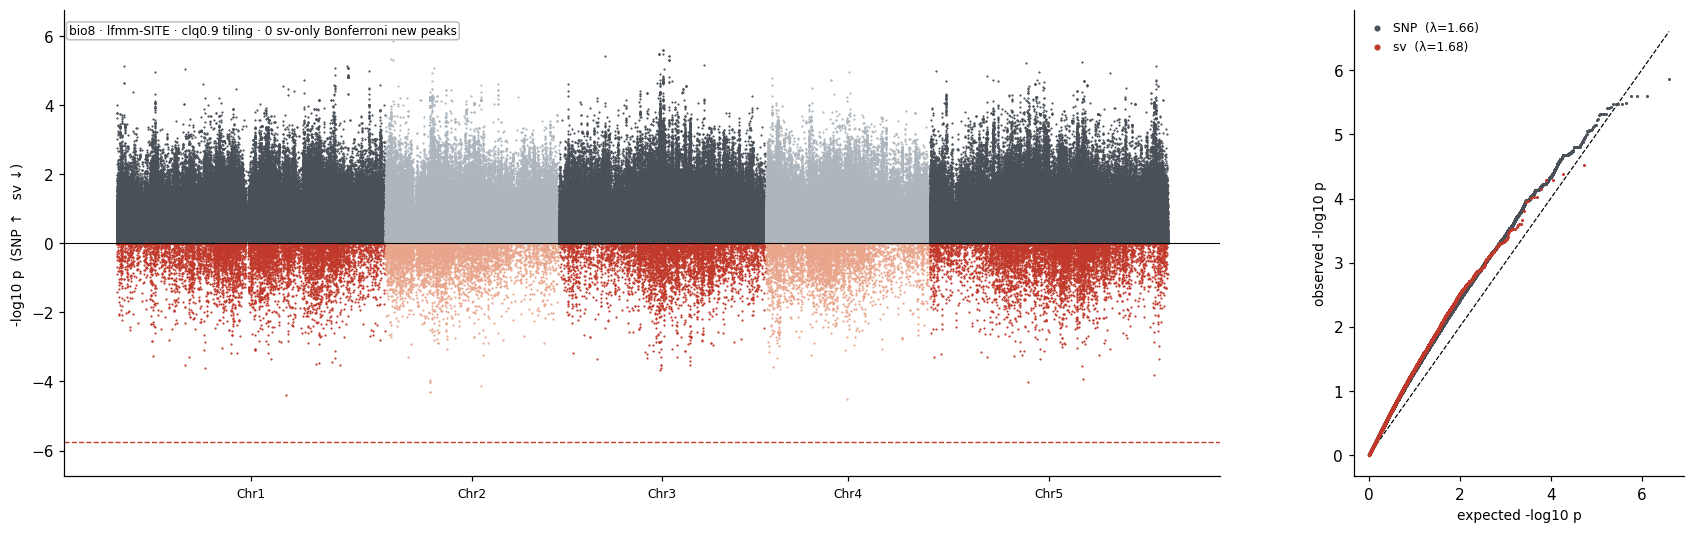

bio8: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


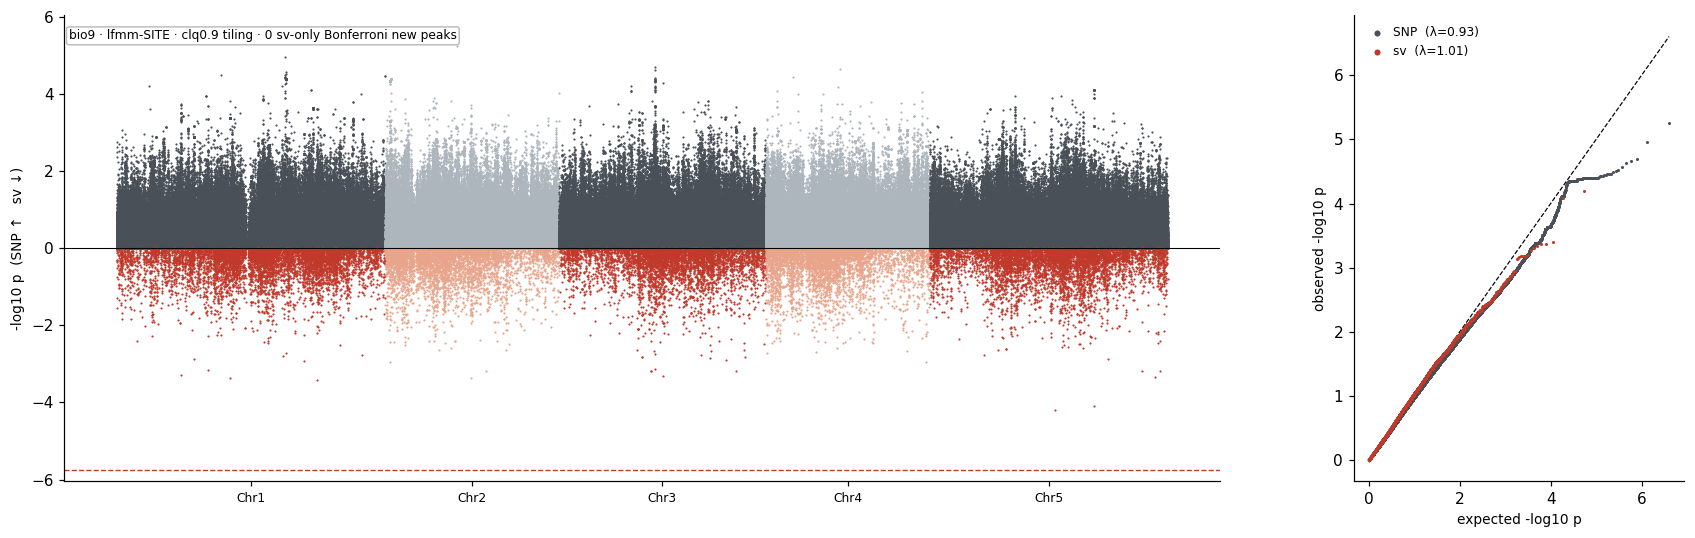

bio9: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


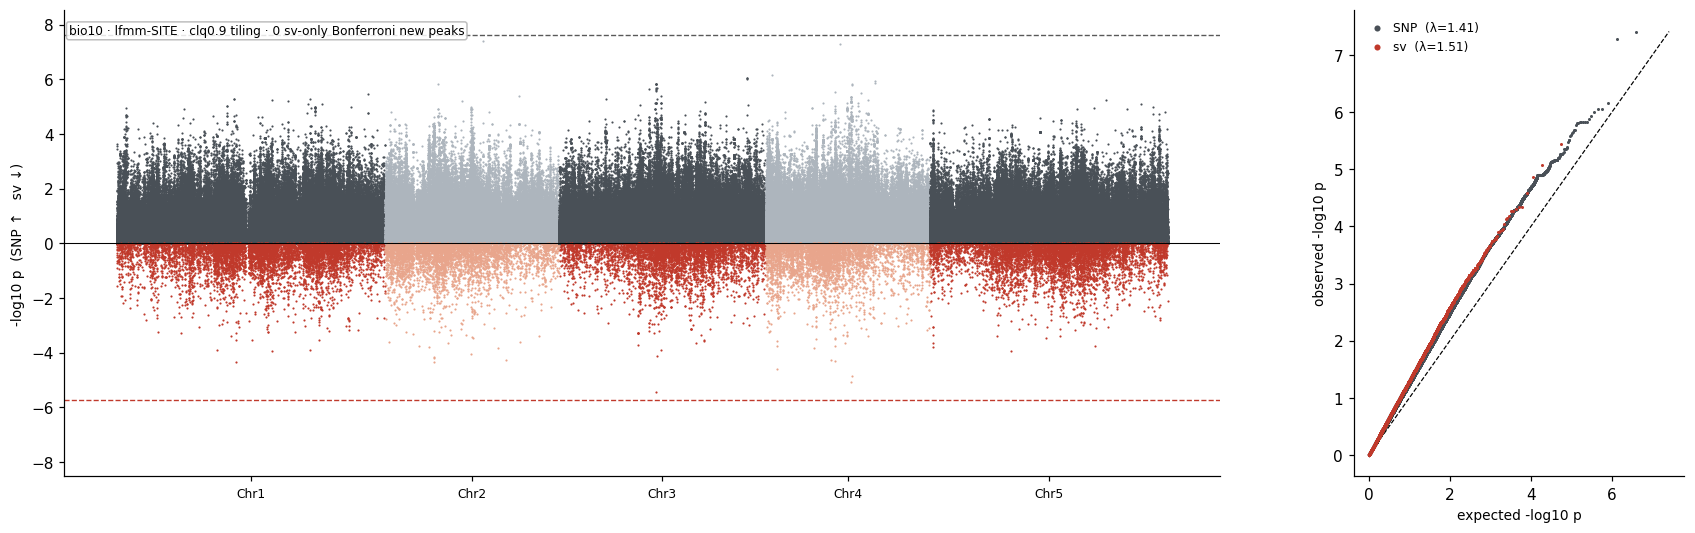

bio10: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


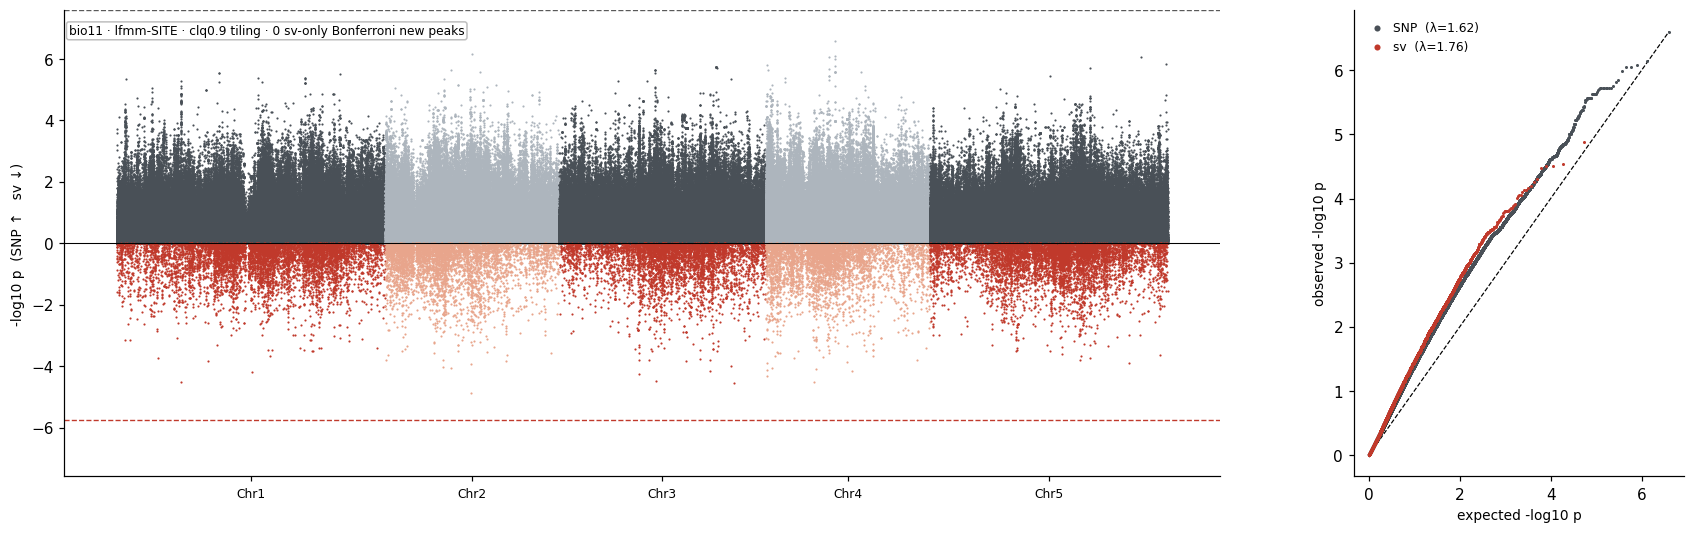

bio11: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


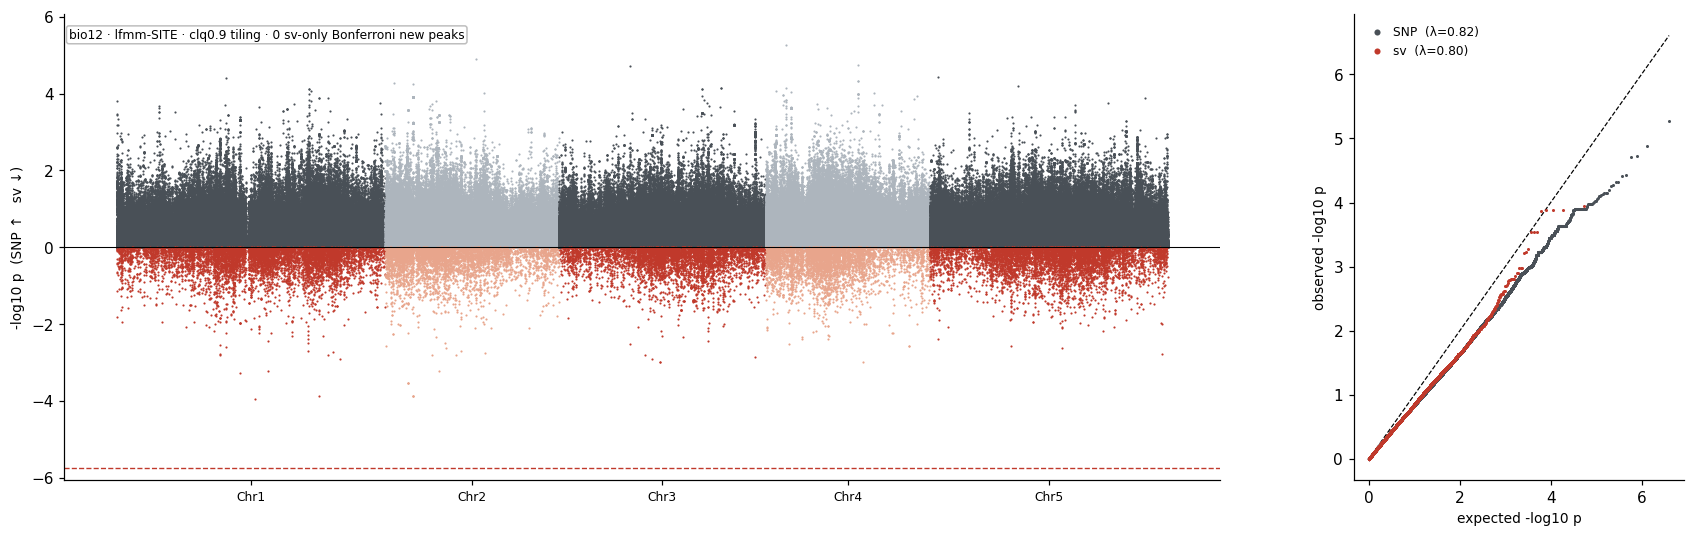

bio12: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


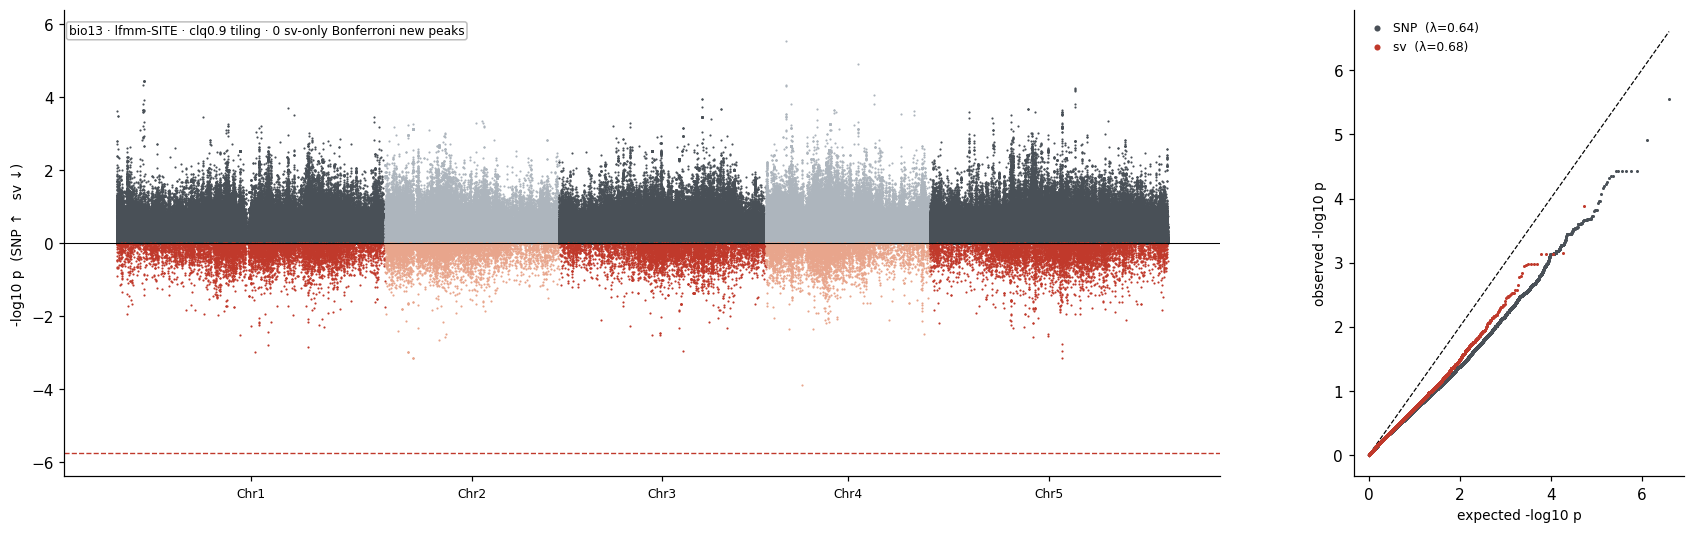

bio13: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


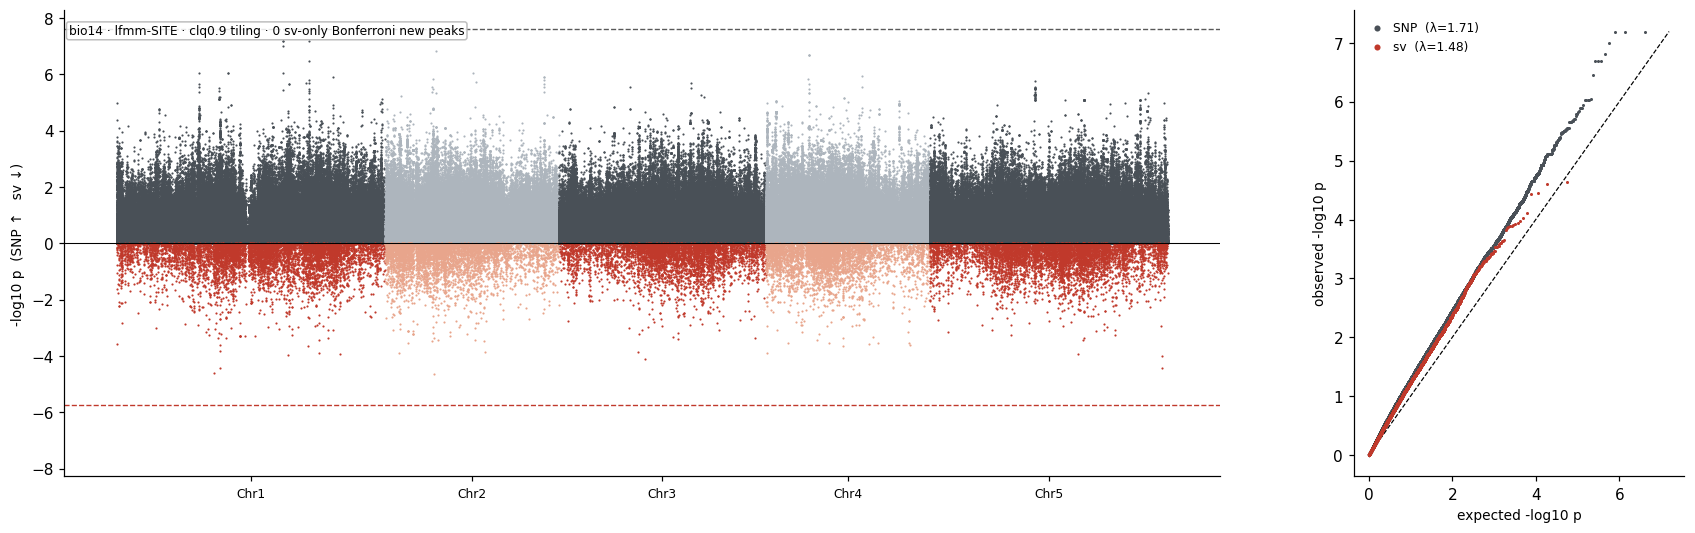

bio14: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


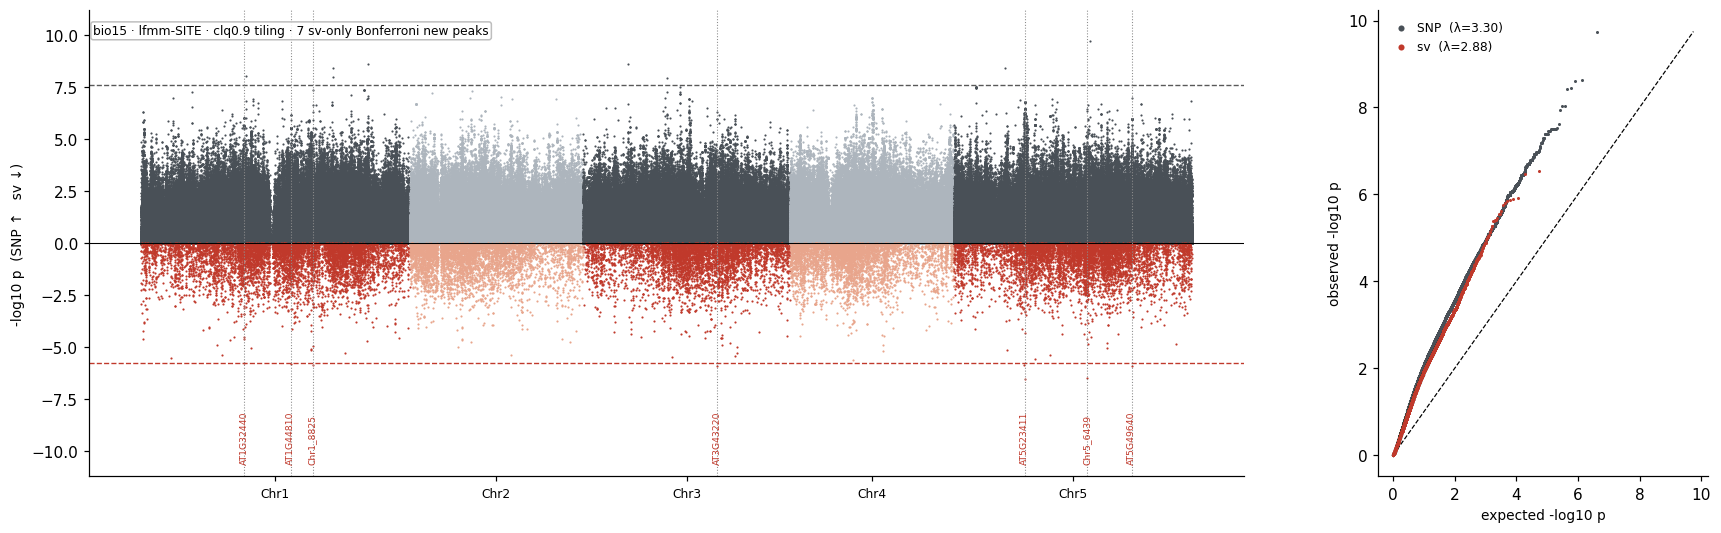

bio15: 7 sv-only Bonferroni new peaks (gene-bearing: 5)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
3808,Chr5_4035,Chr5,8008583,AT5G23411,6.533432,4.624243
4158,Chr5_6439,Chr5,15040225,,6.461700,6.465257
2418,Chr3_6383,Chr3,15205485,AT3G43220,5.917341,6.309536
3462,Chr5_10213,Chr5,20151132,AT5G49640,5.899663,7.013474
1082,Chr1_8825,Chr1,19426362,,5.876632,6.298983
931,Chr1_7508,Chr1,16930015,AT1G44810;AT1G44820,5.803508,3.518900
728,Chr1_6373,Chr1,11710599,AT1G32440,5.762143,5.716067


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


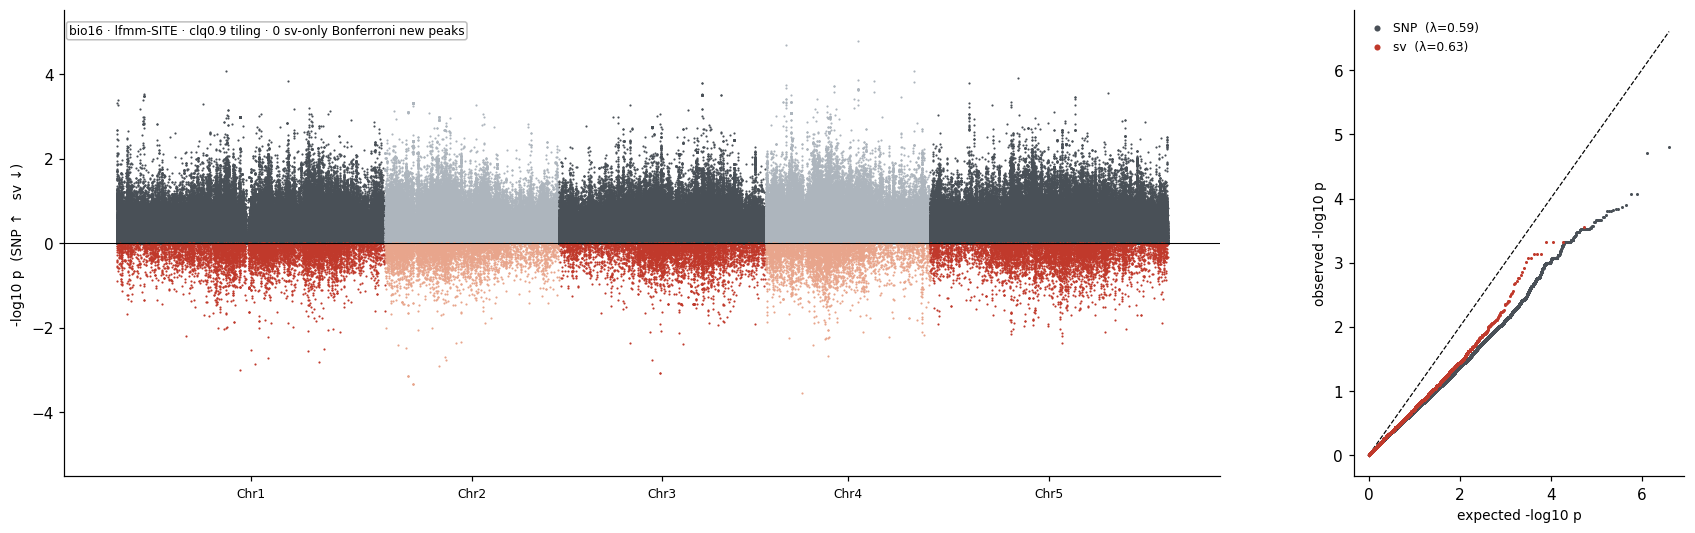

bio16: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


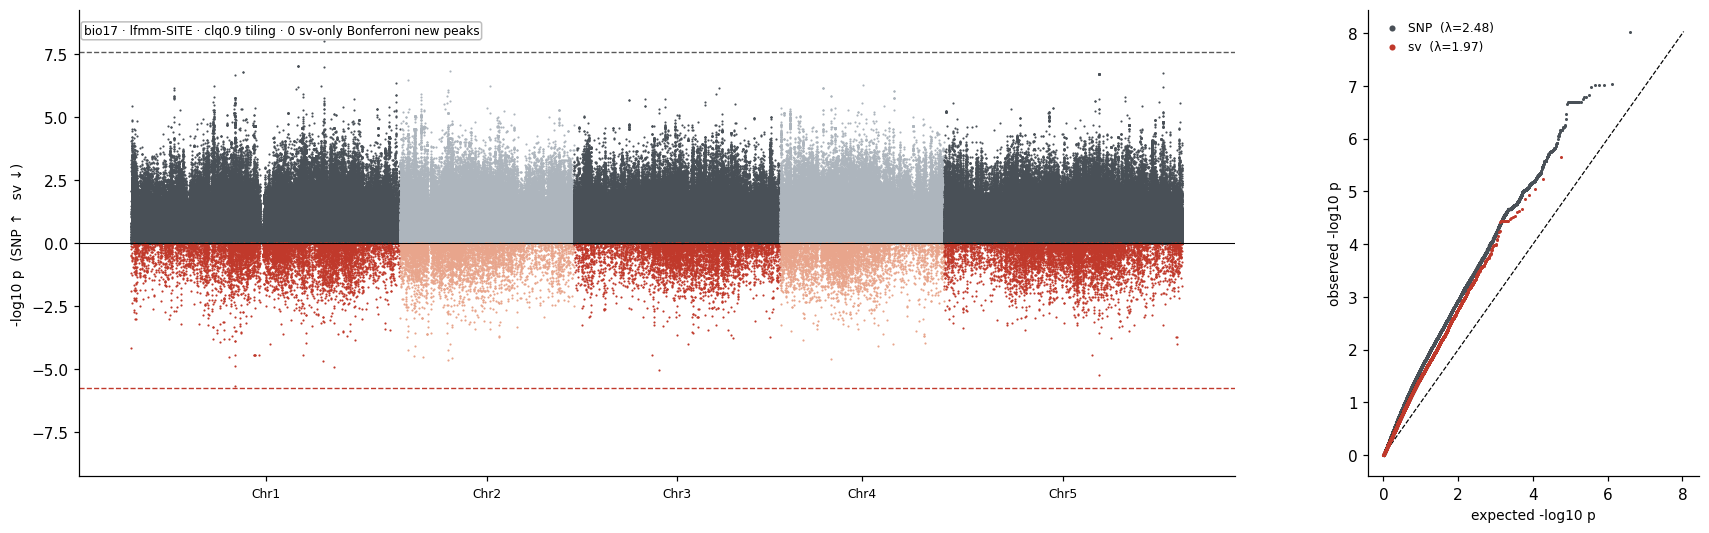

bio17: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


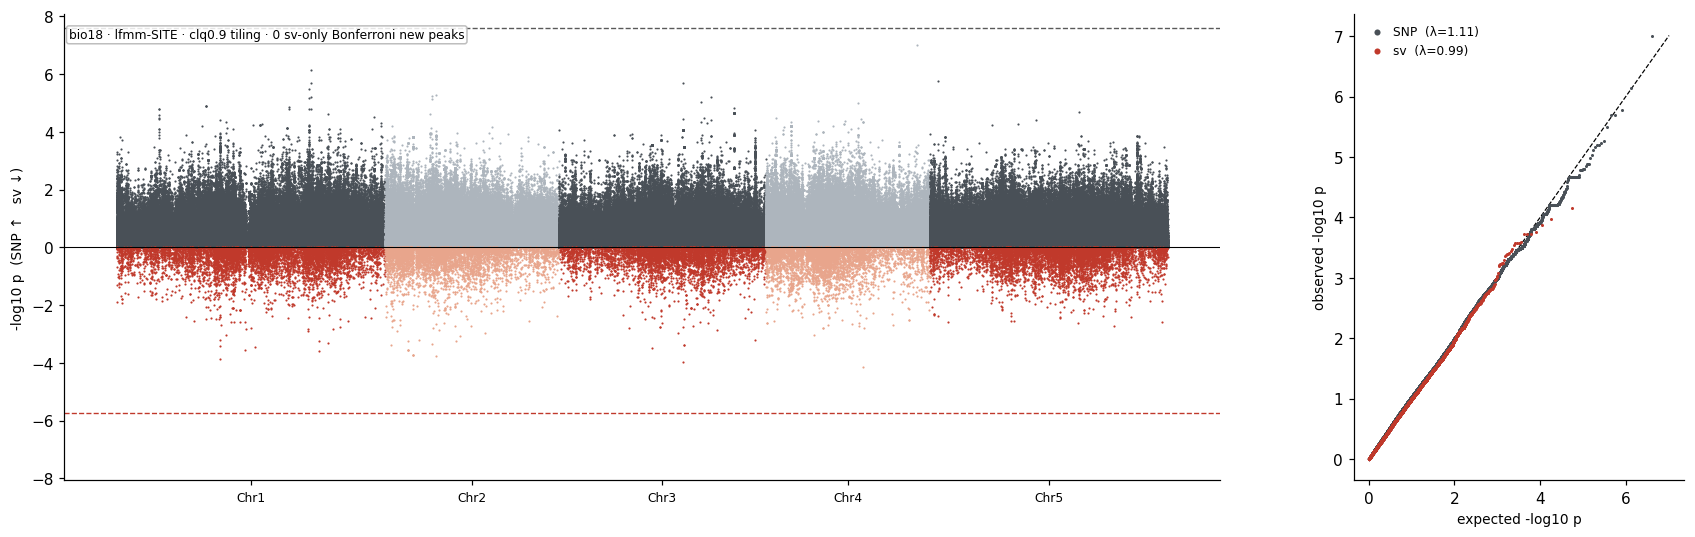

bio18: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


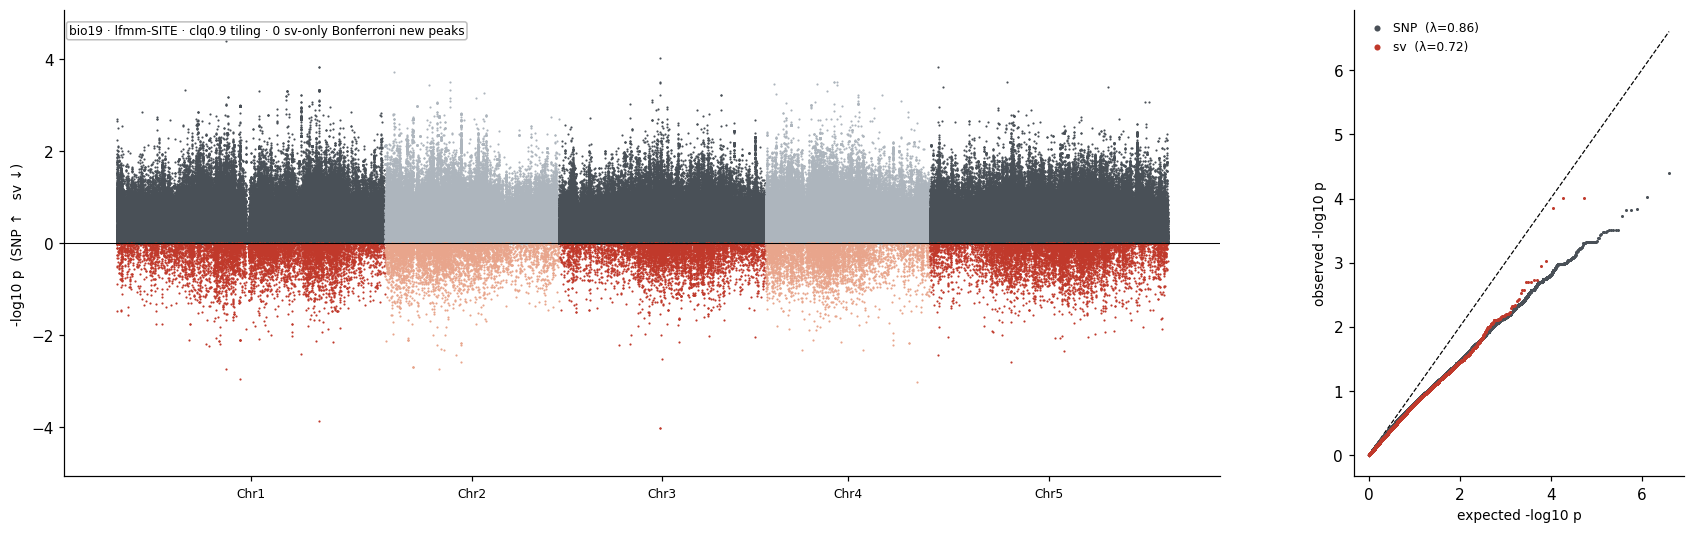

bio19: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_3611409/443451607.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


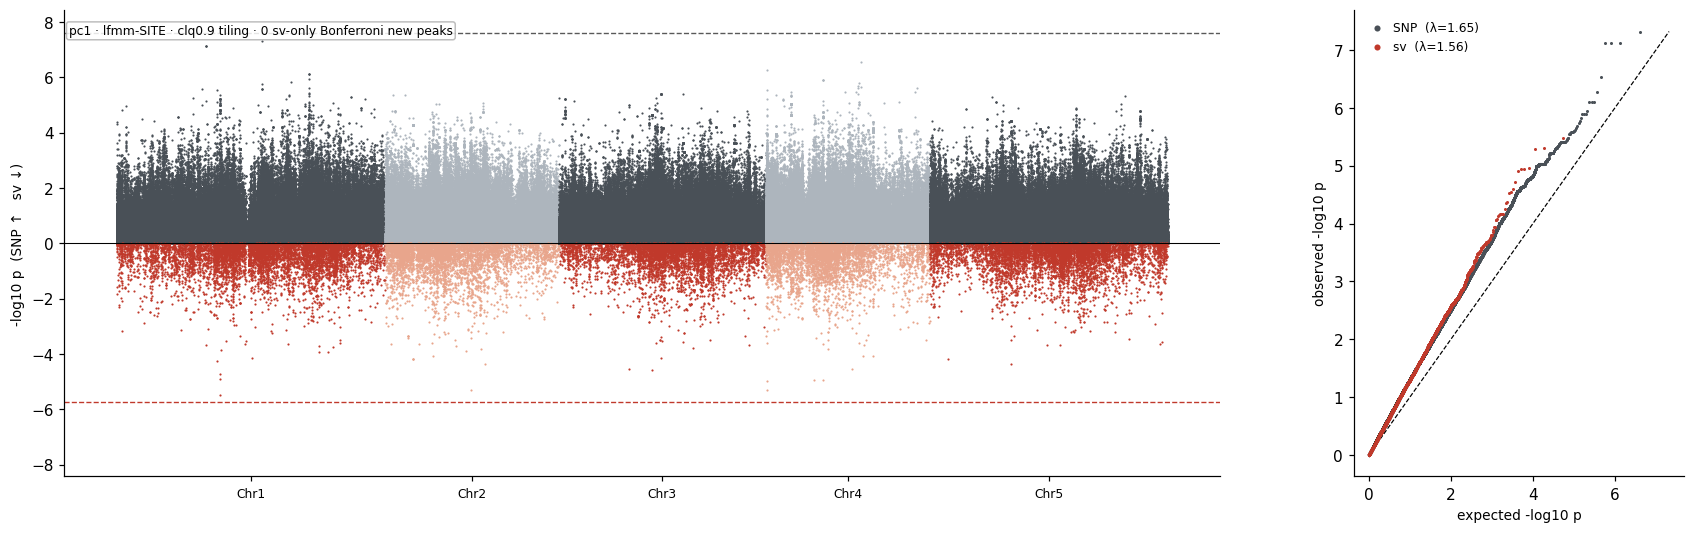

pc1: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


In [2]:
from scipy import stats

def load_raw(cls, axis):
    f = f"{WZAIN}/{MODEL}_{cls}_gen9_{axis}.csv"
    if not os.path.exists(f): return None
    d = pd.read_csv(f)
    d = d[d["MAF"] > 0.05].copy()
    d["nlp"] = -np.log10(d["pval"].clip(lower=1e-300))
    d["gpos"] = d["chrom"].map(OFF) + d["pos"]
    return d

def leads(d):
    d = d[d["block"].notna() & (d["block"] != "")]
    return d.loc[d.groupby("block")["nlp"].idxmax()]

def gif_lambda(p):
    # genomic inflation factor: median observed chi2(1df) / expected median (0.4549)
    p = np.clip(np.asarray(p, float), 1e-300, 1.0)
    chi2 = stats.chi2.isf(p, 1)
    return float(np.median(chi2) / stats.chi2.isf(0.5, 1))

def qq_xy(p, keep_head=15000, n_bulk=3000):
    # observed vs expected -log10p under the uniform null; thin the dense bulk but
    # keep the whole significant tail (small p). Returns (expected, observed).
    p = np.sort(np.clip(np.asarray(p, float)[np.isfinite(p)], 1e-300, 1.0))
    n = len(p)
    exp = -np.log10((np.arange(n) + 0.5) / n)
    obs = -np.log10(p)
    if n <= keep_head + n_bulk:
        idx = np.arange(n)
    else:
        head = np.arange(keep_head)                                   # strongest hits, kept in full
        bulk = np.unique(np.geomspace(keep_head, n - 1, n_bulk).astype(int))
        idx = np.concatenate([head, bulk])
    return exp[idx], obs[idx]

def raw_mirror(ax, axis, cls, s, c):
    bonf_s, bonf_c = -np.log10(0.05/len(s)), -np.log10(0.05/len(c))
    ls_, lc_ = leads(s), leads(c)
    m = lc_.merge(ls_[["block", "nlp"]], on="block", suffixes=("", "_snp"), how="left")
    m["nlp_snp"] = m["nlp_snp"].fillna(0.0)
    newpk = m[(m["nlp"] > bonf_c) & (m["nlp_snp"] <= bonf_s)].copy()
    for i, ch in enumerate(CH):
        ss, cc = s[s.chrom == ch], c[c.chrom == ch]
        ax.scatter(ss.gpos, ss.nlp, s=2, c=(SNP_DARK if i % 2 == 0 else SNP_LIGHT), rasterized=True, linewidths=0)
        ax.scatter(cc.gpos, -cc.nlp, s=2, c=(CLS_DARK if i % 2 == 0 else CLS_LIGHT), rasterized=True, linewidths=0)
    ax.axhline(0, c="k", lw=.7)
    ax.axhline(bonf_s, ls="--", c="0.35", lw=.9)
    ax.axhline(-bonf_c, ls="--", c=CLS_DARK, lw=.9)
    ymax = max(s.nlp.max(), c.nlp.max()) * 1.15
    newpk["genes"] = newpk["block"].map(lambda b: ";".join(genes_on(b)))
    for _, r in newpk.iterrows():
        lab = r.genes.split(";")[0] if r.genes else r.block
        ax.axvline(r.gpos, ls=":", c="0.55", lw=.7)
        ax.annotate(lab, xy=(r.gpos, -ymax*0.95), ha="center", va="bottom", fontsize=6,
                    color=CLS_DARK, rotation=90)
    ax.set_ylim(-ymax, ymax)
    ax.set_xticks([OFF[c]+CHROM_LEN[c]/2 for c in CH]); ax.set_xticklabels(CH, fontsize=8)
    ax.set_ylabel(f"-log10 p  (SNP \u2191   {cls} \u2193)", fontsize=9)
    ax.annotate(f"{axis} \u00b7 lfmm-SITE \u00b7 clq0.9 tiling \u00b7 {len(newpk)} {cls}-only Bonferroni new peaks",
                xy=(0.004, 0.97), xycoords="axes fraction", va="top", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.7", alpha=.85))
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    return newpk[["block", "chrom", "pos", "nlp", "nlp_snp", "genes"]].sort_values("nlp", ascending=False)

def qq_panel(ax, cls, s, c):
    lam_s, lam_c = gif_lambda(s["pval"]), gif_lambda(c["pval"])
    xs, ys = qq_xy(s["pval"].to_numpy()); xc, yc = qq_xy(c["pval"].to_numpy())
    hi = max(xs.max(), ys.max(), xc.max(), yc.max())
    ax.plot([0, hi], [0, hi], c="k", lw=.8, ls="--", zorder=1)                 # null diagonal
    ax.scatter(xs, ys, s=4, c=SNP_DARK, rasterized=True, linewidths=0, zorder=2,
               label=f"SNP  (\u03bb={lam_s:.2f})")
    ax.scatter(xc, yc, s=4, c=CLS_DARK, rasterized=True, linewidths=0, zorder=2,
               label=f"{cls}  (\u03bb={lam_c:.2f})")
    ax.set_xlabel("expected -log10 p", fontsize=9)
    ax.set_ylabel("observed -log10 p", fontsize=9)
    ax.legend(loc="upper left", frameon=False, fontsize=8, markerscale=2, handletextpad=0.3)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    return lam_s, lam_c

all_newpk = []
for axis in AXES:
    s, c = load_raw("snp", axis), load_raw(CLS, axis)
    if s is None or c is None:
        print(f"missing {axis}"); continue
    fig = plt.figure(figsize=(19, 5.5))
    gs = fig.add_gridspec(1, 2, width_ratios=[3.5, 1], wspace=0.18)
    newpk = raw_mirror(fig.add_subplot(gs[0]), axis, CLS, s, c)
    qq_panel(fig.add_subplot(gs[1]), CLS, s, c)
    fig.tight_layout(); plt.show()
    newpk = newpk.copy(); newpk["axis"] = axis
    all_newpk.append(newpk)
    print(f"{axis}: {len(newpk)} {CLS}-only Bonferroni new peaks (gene-bearing: {(newpk.genes != '').sum()})")
    if len(newpk):
        display(newpk[["block", "chrom", "pos", "genes", "nlp", "nlp_snp"]].rename(
            columns={"nlp": f"{CLS}_nlp", "nlp_snp": "snp_nlp_here"}))

## Candidate genes — SV-only new peaks (SITE-collapsed), consolidated across all 20 axes

Union of every gene-bearing new peak found above, deduplicated per gene (kept: the
axis with the strongest sv signal), with Ensembl Plants symbol/description and a
recurrence count (how many of the 20 axes flag that gene's block). **Site-collapsed raw p**
(pseudoreplication removed by pooling to 31 sites; no GIF applied to the plotted p). Compare
this list to the pool `raw_manhattan_newpeak_genes_sv_tile.csv` — genes that drop out here
were pool-pseudoreplication artifacts; genes that persist are site-coherent candidates.

In [3]:
import json, time, urllib.request

ALL = pd.concat(all_newpk, ignore_index=True) if all_newpk else pd.DataFrame(columns=["block","gene","axis","nlp"])
gene_rows = []
for _, r in ALL.iterrows():
    for g in (r.genes.split(";") if r.genes else []):
        gene_rows.append(dict(gene=g, block=r.block, chrom=r.chrom, pos=r.pos, axis=r.axis, nlp=r.nlp))
G = pd.DataFrame(gene_rows)
if len(G):
    recur = G.groupby("gene")["axis"].nunique().rename("n_axes")
    best = G.sort_values("nlp", ascending=False).drop_duplicates("gene").set_index("gene")
    cand = best.join(recur).sort_values("n_axes", ascending=False).reset_index()

    def ensembl_symbols(ids, chunk=900, retries=3):
        out = {}
        for i in range(0, len(ids), chunk):
            sub = ids[i:i + chunk]
            req = urllib.request.Request("https://rest.ensembl.org/lookup/id",
                data=json.dumps({"ids": sub}).encode(),
                headers={"Content-Type": "application/json", "Accept": "application/json"})
            for attempt in range(retries):
                try:
                    with urllib.request.urlopen(req, timeout=60) as r:
                        d = json.load(r)
                    for k, v in d.items():
                        if v:
                            out[k] = (v.get("display_name", "") or "", (v.get("description", "") or "").split(" [Source")[0])
                    break
                except Exception as e:
                    print(f"  [ensembl] chunk {i} attempt {attempt+1}: {e}", flush=True); time.sleep(2)
        return out

    sym = ensembl_symbols(sorted(cand.gene.unique()))
    cand["symbol"] = cand.gene.map(lambda x: sym.get(x, ("", ""))[0])
    cand["description"] = cand.gene.map(lambda x: sym.get(x, ("", ""))[1])
    cand.to_csv(f"{lib.GEA}/phase1_replication/results/multiaxis/raw_manhattan_newpeak_genes_{CLS}_site_tile.csv", index=False)
    print(f"{len(cand)} unique {CLS}-only new-peak genes (site-collapsed) across 20 axes")
    display(cand[["gene", "symbol", "description", "block", "chrom", "pos", "n_axes", "nlp"]].head(50))
else:
    print("no gene-bearing new peaks found on any axis")

10 unique sv-only new-peak genes (site-collapsed) across 20 axes


,gene,symbol,description,block,chrom,pos,n_axes,nlp
0,AT3G29035,NAC3,NAC domain containing protein 3,Chr3_5945,Chr3,11035192,1,6.758382
1,AT3G29040,AT3G29040,"cysteine-rich repeat secretory protein, putati...",Chr3_5945,Chr3,11035192,1,6.758382
2,AT3G29050,AT3G29050,receptor-like protein kinase-like protein,Chr3_5945,Chr3,11035192,1,6.758382
3,AT3G29060,AT3G29060,EXS (ERD1/XPR1/SYG1) family protein,Chr3_5945,Chr3,11035192,1,6.758382
4,AT5G23411,AT5G23411,uncharacterized protein,Chr5_4035,Chr5,8008583,1,6.533432
5,AT3G43220,AT3G43220,Phosphoinositide phosphatase family protein,Chr3_6383,Chr3,15205485,1,5.917341
6,AT5G49640,AT5G49640,uncharacterized protein,Chr5_10213,Chr5,20151132,1,5.899663
7,AT1G44810,AT1G44810,DNA-binding storekeeper protein-related transc...,Chr1_7508,Chr1,16930015,1,5.803508
8,AT1G44820,AT1G44820,Peptidase M20/M25/M40 family protein,Chr1_7508,Chr1,16930015,1,5.803508
9,AT1G32440,PKp3,plastidial pyruvate kinase 3,Chr1_6373,Chr1,11710599,1,5.762143


## Functional theme per gene — stress / climate / flowering / circadian / defense

Same SV-only new-peak gene list (site-collapsed), tagged with a **functional
category** via the project annotator `annotate_genes_tair_uniprot.py` (TAIR GO + UniProt —
the mandated route). Categories: `flowering` (flowering time, vernalization, photoperiod,
**circadian**, meristem identity) · `temperature` (cold/freezing/heat, CBF/DREB/COR) ·
`water` (drought, osmotic, ABA, salinity, stomata) · `light` (photomorphogenesis, UV, shade
avoidance, photosynthesis) · `oxidative` (ROS, abiotic/general stress) · `defense` (immunity,
pathogen, SA/JA, R-genes) · `calcium` (Ca2+/calmodulin/CDPK). A gene can carry several.
Written to `raw_manhattan_newpeak_genes_sv_site_tile_annotated.csv`.

In [4]:
import importlib.util as _ilu

_annp = os.path.abspath(os.path.join(os.getcwd(), "..", "annotate_genes_tair_uniprot.py"))
_sp = _ilu.spec_from_file_location("ann_tu", _annp)
ann_tu = _ilu.module_from_spec(_sp); _sp.loader.exec_module(ann_tu)

if "cand" in dir() and len(cand):
    _A = ann_tu.annotate(sorted(cand["gene"].unique()))
    _cols = ["gene", "protein_name", "categories", "climate_stress_flowering",
             "uniprot_function", "uniprot_keywords"]
    cand_annot = cand.merge(_A[_cols], on="gene", how="left")
    cand_annot["categories"] = cand_annot["categories"].fillna("")
    _outp = f"{lib.GEA}/phase1_replication/results/multiaxis/raw_manhattan_newpeak_genes_{CLS}_site_tile_annotated.csv"
    cand_annot.to_csv(_outp, index=False)
    _ntag = int((cand_annot["categories"].str.len() > 0).sum())
    print(f"{len(cand_annot)} genes annotated ; {_ntag} tagged to >=1 climate/stress/flowering/defense category")
    print("\ncategory counts (a gene can carry several):")
    print(cand_annot["categories"].str.split(",").explode().replace("", pd.NA)
          .dropna().value_counts().to_string())
    display(cand_annot[["gene", "symbol", "protein_name", "categories", "n_axes",
                        "nlp", "chrom", "pos"]].sort_values(["n_axes", "nlp"],
                        ascending=False).head(60))
else:
    cand_annot = pd.DataFrame(columns=["gene", "symbol", "categories"])
    print("no genes to annotate")

annotating 10 genes

-- TAIR GAF (GO Consortium) --


GAF cache: /global/scratch/projects/fc_moilab/tbellg/kmate/analysis/grenenet_gea/phase1_replication/results/cache/tair.gaf.gz (7.2 MB)


   GO for 9/10 genes
-- UniProt REST pass 1: reviewed / Swiss-Prot (taxid 3702) --


  uniprot 10/10 -> 7 mapped


   reviewed: 7/10 genes
-- UniProt REST pass 2: unreviewed / TrEMBL for the remaining 3 --


  uniprot 3/3 -> 3 mapped


   UniProt total: 10/10 genes
-- mygene.info (kept for GO term NAMES + entrez) --


10 genes annotated ; 2 tagged to >=1 climate/stress/flowering/defense category

category counts (a gene can carry several):
categories
oxidative    1
defense      1


,gene,symbol,protein_name,categories,n_axes,nlp,chrom,pos
0,AT3G29035,NAC3,NAC domain-containing protein 59 (ANAC059) (At...,oxidative,1,6.758382,Chr3,11035192
1,AT3G29040,AT3G29040,Putative cysteine-rich repeat secretory protei...,,1,6.758382,Chr3,11035192
2,AT3G29050,AT3G29050,Putative cysteine-rich repeat secretory protei...,,1,6.758382,Chr3,11035192
3,AT3G29060,AT3G29060,Phosphate transporter PHO1 homolog 9 (Protein ...,,1,6.758382,Chr3,11035192
4,AT5G23411,AT5G23411,Uncharacterized protein,,1,6.533432,Chr5,8008583
5,AT3G43220,AT3G43220,Phosphoinositide phosphatase SAC3 (AtSAC3) (EC...,,1,5.917341,Chr3,15205485
6,AT5G49640,AT5G49640,Uncharacterized protein,,1,5.899663,Chr5,20151132
7,AT1G44810,AT1G44810,Probable transcription factor At1g44810 (Store...,defense,1,5.803508,Chr1,16930015
8,AT1G44820,AT1G44820,Aminoacylase like protein,,1,5.803508,Chr1,16930015
9,AT1G32440,PKp3,"Plastidial pyruvate kinase 3, chloroplastic (P...",,1,5.762143,Chr1,11710599


## Dot plot — recurrent SV-only new-peak genes (site-collapsed) across the 20 climate axes

One dot per (gene, axis) where that gene's block is an sv-only Bonferroni new peak on
that axis. **Dot size** = -log10 p (that axis' sv lead); **color** = functional category
(above). Genes are ordered genomically (chrom then position) and the panel is limited to
genes recurring on **enough axes to stay legible** (auto-threshold, printed below); the full
gene list with categories is the table above. Reading across a row shows how many of the 20
climate variables independently flag that gene's block at site level.

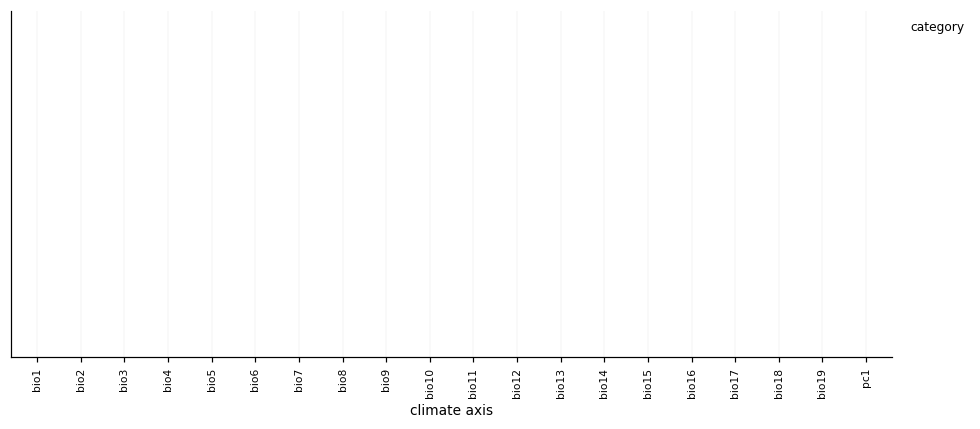

dot plot: 0 genes recurring on >=2 of 20 axes (auto-threshold for legibility); 10 of 10 lower-recurrence genes omitted from the plot but present in the annotated table/CSV.


In [5]:
import matplotlib.lines as mlines

AXES_ORD = [f"bio{i}" for i in range(1, 20)] + ["pc1"]
_rows = []
if all_newpk:
    for r in pd.concat(all_newpk, ignore_index=True).itertuples():
        for g in (r.genes.split(";") if r.genes else []):
            _rows.append(dict(gene=g, axis=r.axis, nlp=r.nlp, chrom=r.chrom, pos=r.pos))
GX = pd.DataFrame(_rows)

if len(GX):
    _nax = GX.groupby("gene")["axis"].nunique()
    thr = 2
    while int((_nax >= thr).sum()) > 70 and thr < 8:
        thr += 1
    keep_genes = set(_nax[_nax >= thr].index)
    D = GX[GX["gene"].isin(keep_genes)].drop_duplicates(["gene", "axis"]).copy()
    gord = (D.drop_duplicates("gene")
            .assign(_cn=lambda x: x["chrom"].str.replace("Chr", "", regex=False).astype(int))
            .sort_values(["_cn", "pos"])["gene"].tolist())
    catmap = dict(zip(cand_annot["gene"], cand_annot["categories"])) if len(cand_annot) else {}
    symmap = dict(zip(cand_annot["gene"], cand_annot["symbol"])) if len(cand_annot) else {}
    def _pcat(g):
        c = [x for x in (catmap.get(g, "") or "").split(",") if x]
        return c[0] if c else "unclassified"
    CATCOL = {"flowering": "#8E44AD", "temperature": "#2980B9", "water": "#16A085",
              "light": "#F1C40F", "oxidative": "#E67E22", "defense": "#C0392B",
              "calcium": "#7F8C8D", "unclassified": "#CED4DA"}
    yidx = {g: i for i, g in enumerate(gord)}
    xidx = {a: i for i, a in enumerate(AXES_ORD)}
    fig, ax = plt.subplots(figsize=(9, max(4, 0.26 * len(gord))))
    for _, rr in D.iterrows():
        ax.scatter(xidx[rr["axis"]], yidx[rr["gene"]], s=12 + rr["nlp"] * 2.2,
                   c=CATCOL.get(_pcat(rr["gene"]), "#CED4DA"), edgecolors="white",
                   linewidths=0.3, alpha=0.95, zorder=3)
    ax.set_xticks(range(len(AXES_ORD))); ax.set_xticklabels(AXES_ORD, rotation=90, fontsize=7)
    ax.set_yticks(range(len(gord)))
    ax.set_yticklabels([f"{(symmap.get(g) or g)}  ({_pcat(g)})" for g in gord], fontsize=6)
    ax.set_xlim(-0.6, len(AXES_ORD) - 0.4); ax.set_ylim(-0.7, len(gord) - 0.3)
    ax.grid(True, axis="both", lw=0.3, c="0.9", zorder=0); ax.set_axisbelow(True)
    ax.set_xlabel("climate axis", fontsize=9)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    _present = [c for c in CATCOL if c in {_pcat(g) for g in gord}]
    _h = [mlines.Line2D([], [], marker="o", ls="", ms=7, mfc=CATCOL[c], mec="white", label=c)
          for c in _present]
    ax.legend(handles=_h, title="category", loc="upper left", bbox_to_anchor=(1.01, 1.0),
              frameon=False, fontsize=7, title_fontsize=8)
    fig.tight_layout(); plt.show()
    _tot = GX["gene"].nunique()
    print(f"dot plot: {len(gord)} genes recurring on >={thr} of 20 axes "
          f"(auto-threshold for legibility); {_tot - len(gord)} of {_tot} lower-recurrence "
          f"genes omitted from the plot but present in the annotated table/CSV.")
else:
    print("no gene-bearing new peaks to plot")

## FDR-relaxed gene list — SV-only new peaks at BH **q < 0.05** (site-collapsed)

The mirror-Manhattans above call new peaks at the stringent per-record **Bonferroni** bar
(0.05/n). Here we relax to a **Benjamini–Hochberg FDR** of **q < 0.05**, computed on the same
site-level RAW p (per class, genome-wide within each axis). A "sv-only FDR new peak" = a
tiling block whose lead sv record clears q<0.05 while its lead SNP record does not — the FDR
analogue of the Bonferroni new-peak rule. Consolidated across all 20 axes, deduplicated per gene
(kept: strongest sv q), TAIR/UniProt-annotated, written to
`raw_manhattan_newpeak_genes_sv_site_tile_FDR.csv`.

**Caveat:** FDR is applied to the RAW (uncalibrated) p, so on the inflated axes (site λ up to
~3 on bio15/bio17) this list will inherit that inflation — read the per-axis λ in the QQ panels
above when weighing these genes.

In [1]:

import os, sys, importlib.util as _ilu
import numpy as np, pandas as pd
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import lib
GEA = lib.GEA
WZAIN = f"{GEA}/phase1_replication/results/multiaxis/wza_in_clq09_tile_site"
AXES = [f"bio{i}" for i in range(1, 20)] + ["pc1"]
CLS = "sv"; QCUT = 0.05

def _spans(r2=0.9):
    tag = f"clq{r2}"; rows = []
    for ci in range(1, 6):
        ch = f"Chr{ci}"
        g = pd.read_csv(f"{lib.CLQ_BLOCKS_DIR}/chr{ci}_{tag}_blocks_{tag}.tsv", sep="\t").sort_values("start_pos").reset_index(drop=True)
        ends = g.end_pos.to_numpy(np.int64)
        for i in range(len(g)):
            lo = 1 if i == 0 else int(ends[i-1]) + 1
            hi = int(ends[i]) if i < len(g)-1 else 10**9
            rows.append((f"{ch}_{i}", ch, lo, hi))
    return pd.DataFrame(rows, columns=["block", "chrom", "start", "end"]).set_index("block")
SPANS = _spans(); GENES = lib.load_genes()
def genes_on(b):
    if b not in SPANS.index: return []
    s = SPANS.loc[b]; gc = GENES[(GENES.chrom == s.chrom) & (GENES.end >= s.start) & (GENES.start <= s.end)]
    return list(gc.gene)

def bh_q(p):
    p = np.asarray(p, float); n = len(p); o = np.argsort(p)
    ranked = (p[o] * n) / np.arange(1, n + 1)
    qo = np.minimum.accumulate(ranked[::-1])[::-1]
    q = np.empty(n); q[o] = np.clip(qo, 0, 1); return q

def load_q(cls, axis):
    f = f"{WZAIN}/lfmm_{cls}_gen9_{axis}.csv"
    if not os.path.exists(f): return None
    d = pd.read_csv(f); d = d[d["MAF"] > 0.05].copy()
    d["q"] = bh_q(d["pval"].to_numpy()); d["nlp"] = -np.log10(d["pval"].clip(lower=1e-300))
    return d

def leads_q(d):
    d = d[d["block"].notna() & (d["block"] != "")]
    return d.loc[d.groupby("block")["q"].idxmin()]

rows = []
for axis in AXES:
    s = load_q("snp", axis); c = load_q(CLS, axis)
    if s is None or c is None:
        print(f"missing {axis}"); continue
    ls_ = leads_q(s)[["block", "q"]].rename(columns={"q": "q_snp"})
    lc_ = leads_q(c)
    m = lc_.merge(ls_, on="block", how="left"); m["q_snp"] = m["q_snp"].fillna(1.0)
    nk = m[(m["q"] < QCUT) & (m["q_snp"] >= QCUT)].copy()
    nk["genes"] = nk["block"].map(lambda b: ";".join(genes_on(b))); nk["axis"] = axis
    rows.append(nk[["block", "chrom", "pos", "q", "nlp", "genes", "axis"]])
    print(f"{axis}: {len(nk)} {CLS}-only FDR(q<{QCUT}) new peaks (gene-bearing {(nk.genes != '').sum()})")
ALLF = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=["block","chrom","pos","q","nlp","genes","axis"])

gr = []
for _, r in ALLF.iterrows():
    for g in (r.genes.split(";") if r.genes else []):
        gr.append(dict(gene=g, block=r.block, chrom=r.chrom, pos=r.pos, axis=r.axis, q=r.q, nlp=r.nlp))
GF = pd.DataFrame(gr)
if len(GF):
    recur = GF.groupby("gene")["axis"].nunique().rename("n_axes")
    best = GF.sort_values("q").drop_duplicates("gene").set_index("gene")
    candf = best.join(recur).sort_values(["n_axes", "q"], ascending=[False, True]).reset_index()
    _annp = os.path.abspath(os.path.join(os.getcwd(), "..", "annotate_genes_tair_uniprot.py"))
    _sp = _ilu.spec_from_file_location("ann_tu", _annp); _ann = _ilu.module_from_spec(_sp); _sp.loader.exec_module(_ann)
    _A = _ann.annotate(sorted(candf["gene"].unique()))
    candf = candf.merge(_A[["gene", "protein_name", "categories", "uniprot_function"]], on="gene", how="left")
    candf["categories"] = candf["categories"].fillna("")
    _out = f"{GEA}/phase1_replication/results/multiaxis/raw_manhattan_newpeak_genes_{CLS}_site_tile_FDR.csv"
    candf.to_csv(_out, index=False)
    _ntag = int((candf["categories"].str.len() > 0).sum())
    print(f"\n{len(candf)} unique {CLS}-only FDR(q<{QCUT}) new-peak genes across 20 axes "
          f"({_ntag} climate/stress/flowering/defense-tagged); wrote {os.path.basename(_out)}")
    print("category counts:")
    print(candf["categories"].str.split(",").explode().replace("", pd.NA).dropna().value_counts().to_string())
    display(candf[["gene", "protein_name", "categories", "block", "chrom", "pos", "n_axes", "q", "nlp"]].head(80))
else:
    print("no gene-bearing FDR new peaks on any axis")


bio1: 1 sv-only FDR(q<0.05) new peaks (gene-bearing 1)


bio2: 0 sv-only FDR(q<0.05) new peaks (gene-bearing 0)


bio3: 0 sv-only FDR(q<0.05) new peaks (gene-bearing 0)


bio4: 0 sv-only FDR(q<0.05) new peaks (gene-bearing 0)


bio5: 0 sv-only FDR(q<0.05) new peaks (gene-bearing 0)


...

   reviewed: 45/81 genes
-- UniProt REST pass 2: unreviewed / TrEMBL for the remaining 36 --


  uniprot 36/36 -> 34 mapped


   UniProt total: 79/81 genes
-- mygene.info (kept for GO term NAMES + entrez) --



81 unique sv-only FDR(q<0.05) new-peak genes across 20 axes (18 climate/stress/flowering/defense-tagged); wrote raw_manhattan_newpeak_genes_sv_site_tile_FDR.csv
category counts:
categories
defense        11
temperature     6
oxidative       3
water           3
light           2
calcium         2
flowering       1


,gene,protein_name,categories,block,chrom,pos,n_axes,q,nlp
0,AT2G22760,Transcription factor bHLH19 (Basic helix-loop-...,,Chr2_3298,Chr2,9686790,2,0.041553,5.344965
1,AT5G62780,Chaperone DnaJ-domain superfamily protein,,Chr5_13068,Chr5,25216556,1,0.012775,4.842960
2,AT5G62790,1-deoxy-D-xylulose 5-phosphate reductoisomeras...,,Chr5_13068,Chr5,25216556,1,0.012775,4.842960
3,AT1G67840,"Chloroplast sensor kinase, chloroplastic (EC 2...",light,Chr1_12985,Chr1,25577146,1,0.014638,4.706996
4,AT1G28670,GDSL esterase/lipase At1g28670 (EC 3.1.1.-) (E...,,Chr1_5408,Chr1,10076857,1,0.015183,4.679561
...,...,...,...,...,...,...,...,...,...
75,AT1G40104,Uncharacterized protein,,Chr1_7218,Chr1,14509396,1,0.049276,4.448342
76,AT1G30925,Putative F-box protein At1g30925,,Chr1_5875,Chr1,11008252,1,0.049276,4.498963
77,AT1G40083,Uncharacterized protein,,Chr1_7218,Chr1,14509396,1,0.049276,4.448342
78,AT1G38950,,,Chr1_7218,Chr1,14509396,1,0.049276,4.448342
